In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# **Explotary Data analysis (EDA)**

In [2]:
df = pd.read_csv("../data/nairobi-city-air-quality.csv")
df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)
df.head()

,timestamp,P2
0,09/01/2018 00:00,34.43
1,09/01/2018 00:05,30.53
2,09/01/2018 00:10,22.80
3,09/01/2018 00:15,13.30
4,09/01/2018 00:20,16.57


In [3]:
df.shape

(32907, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32907 entries, 0 to 32906
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  32907 non-null  str    
 1   P2         32907 non-null  float64
dtypes: float64(1), str(1)
memory usage: 514.3 KB


In [5]:
df["P2"].describe()

count    32907.000000
mean         9.144862
std          7.709263
min          0.950000
25%          5.400000
50%          7.700000
75%         10.950000
max        703.200000
Name: P2, dtype: float64

# **Checking for Outliers**

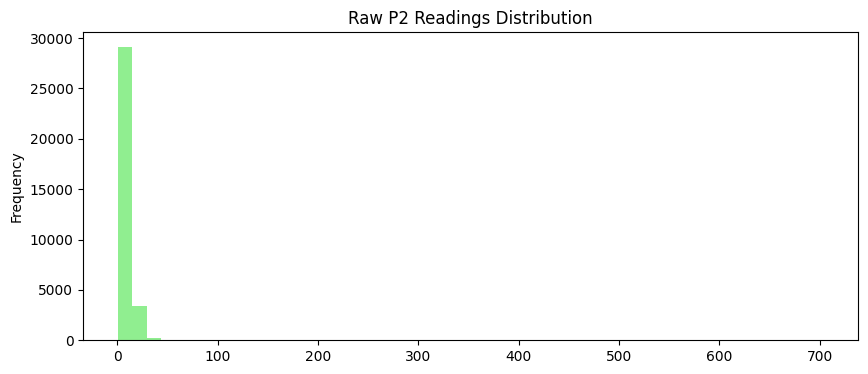

In [6]:
plt.figure(figsize=(10,4))
df["P2"].plot(kind="hist", bins=50, color="lightgreen")
plt.title("Raw P2 Readings Distribution")
plt.show()


In [7]:
# a handful of sensor readings are way out of range (sensor glitches probably)
(df["P2"] > 500).sum()

np.int64(1)

# **Cleaning columns / feature engineering**

In [8]:
# testing cleaning steps loose before wrapping into a function
df_test = df.copy()
df_test["timestamp"] = pd.to_datetime(df_test["timestamp"], format="mixed")
df_test = df_test.set_index("timestamp")
df_test.index = df_test.index.tz_localize("Africa/Nairobi")

df_test = df_test[df_test["P2"] < 500]

y_test_build = df_test["P2"].resample("1h").mean().ffill()
y_test_build.shape

(2928,)

In [9]:
# good, wrap it into a wrangle function
def wrangle(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
    df = df.set_index("timestamp")
    df.index = df.index.tz_localize("Africa/Nairobi")

    # drop sensor glitch readings above 500
    df = df[df["P2"] < 500]

    # resample to hourly mean, forward-fill any gaps
    y = df["P2"].resample("1h").mean().ffill()
    return y


In [10]:
y = wrangle("../data/nairobi-city-air-quality.csv")
y.head()

timestamp
2018-09-01 00:00:00+03:00    17.541667
2018-09-01 01:00:00+03:00    15.800000
2018-09-01 02:00:00+03:00    11.420000
2018-09-01 03:00:00+03:00    11.614167
2018-09-01 04:00:00+03:00    17.665000
Freq: h, Name: P2, dtype: float64

In [11]:
y.shape

(2928,)

In [12]:
# any nulls left after ffill?
y.isnull().sum()

np.int64(0)

# **Explore**

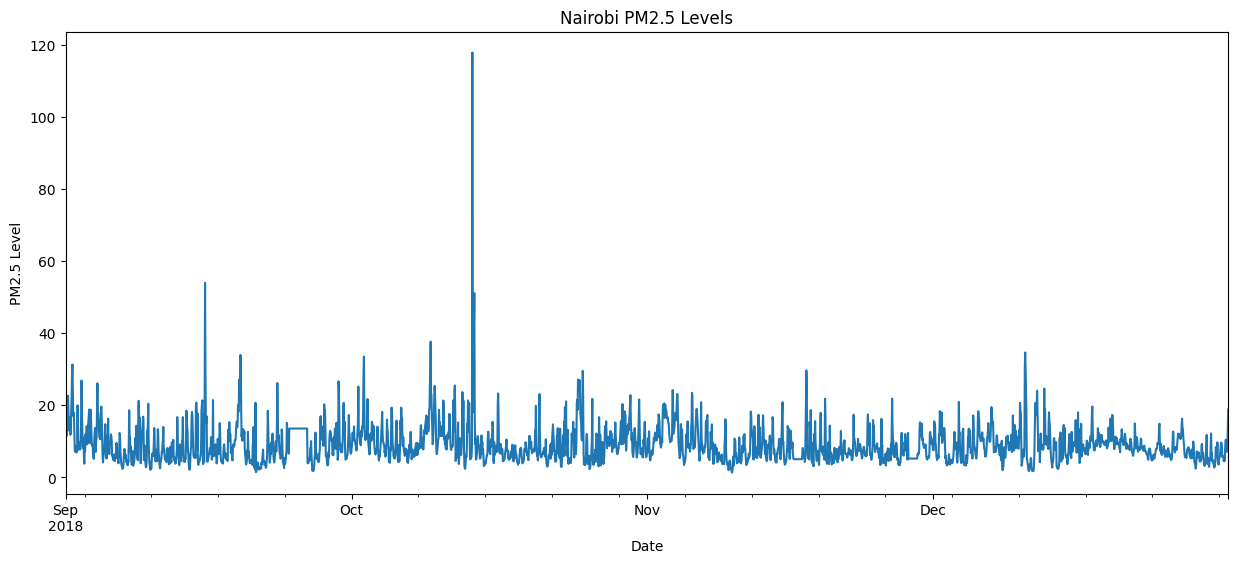

In [13]:
fig, ax = plt.subplots(figsize=(15,6))
y.plot(ax=ax, xlabel="Date", ylabel="PM2.5 Level", title="Nairobi PM2.5 Levels")
plt.savefig("../images/pm25_timeseries.png", dpi=150)
plt.show()


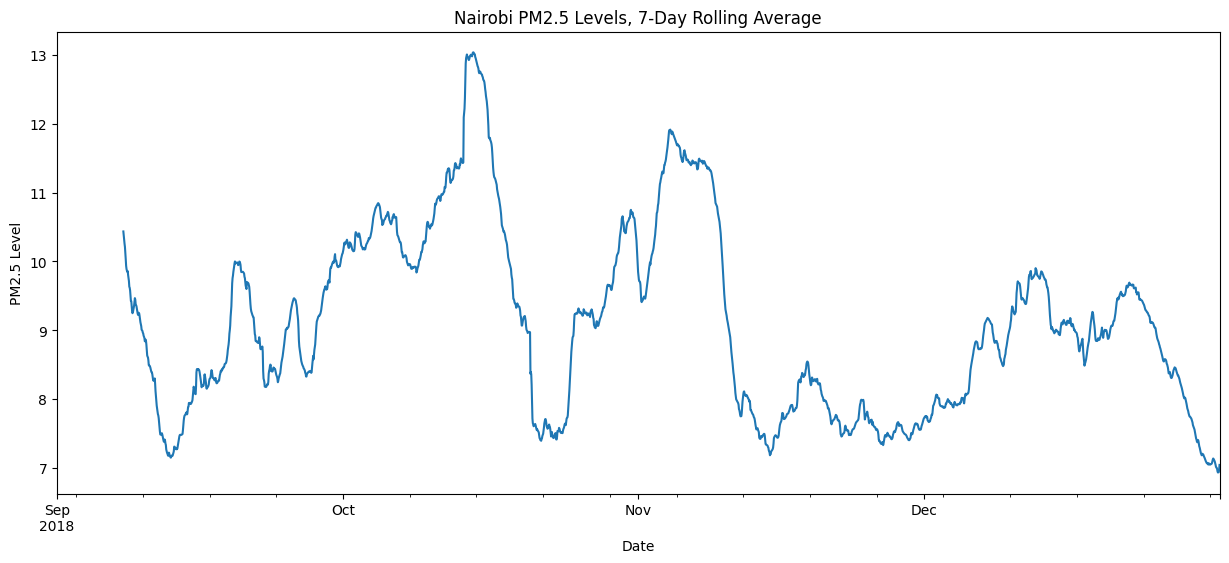

In [14]:
# 7-day rolling average to see the trend without the hourly noise
fig, ax = plt.subplots(figsize=(15,6))
y.rolling(168).mean().plot(ax=ax, xlabel="Date", ylabel="PM2.5 Level",
                            title="Nairobi PM2.5 Levels, 7-Day Rolling Average")
plt.savefig("../images/pm25_rolling_avg.png", dpi=150)
plt.show()


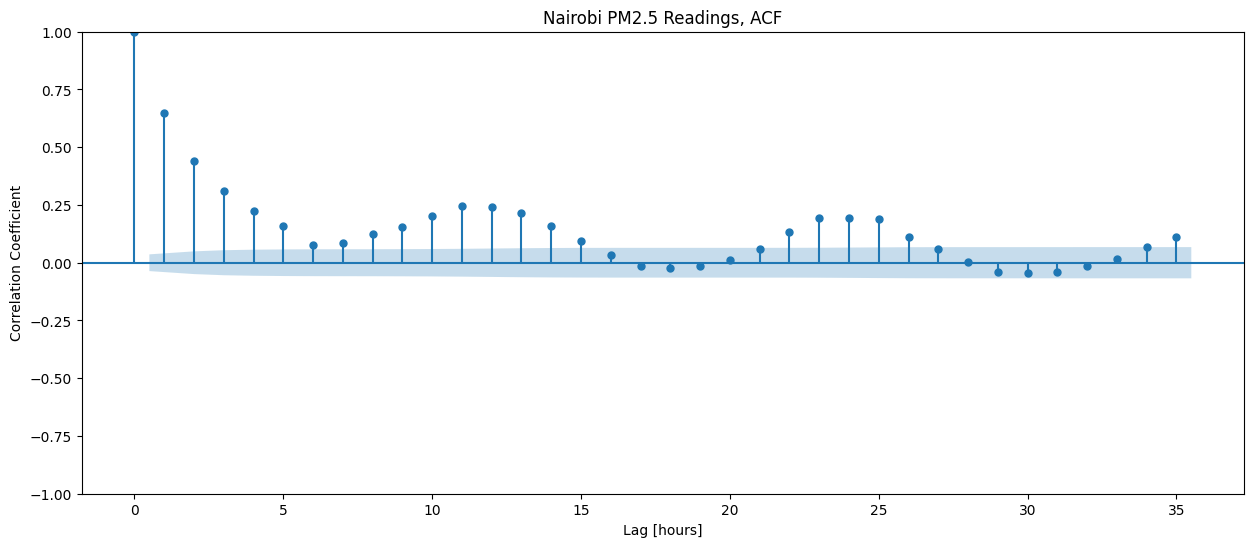

In [15]:
fig, ax = plt.subplots(figsize=(15,6))
plot_acf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, ACF")
plt.savefig("../images/acf.png", dpi=150)
plt.show()


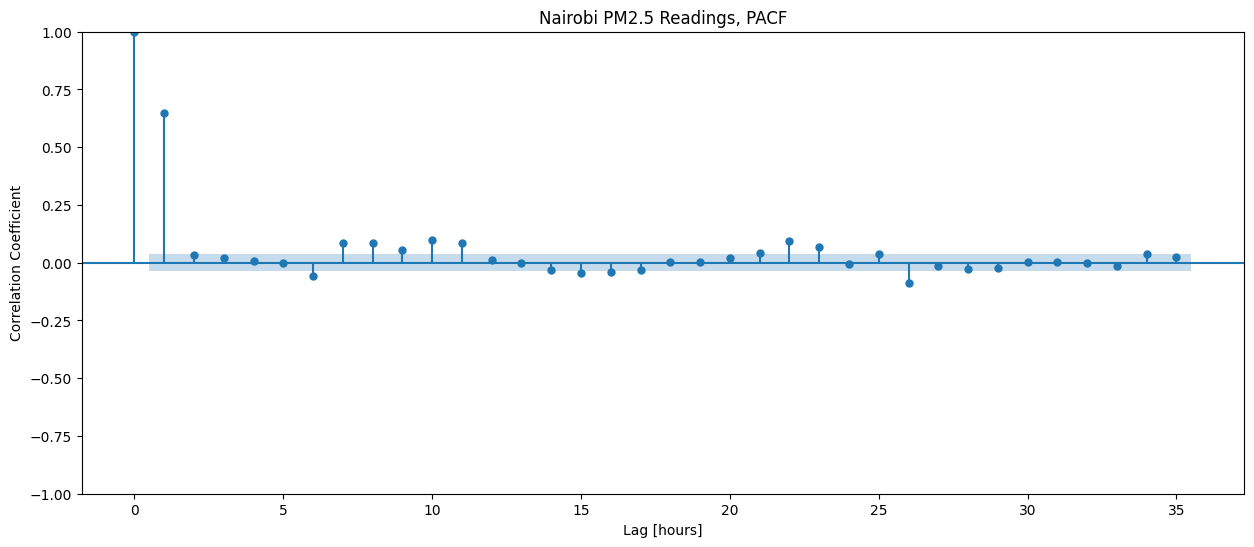

In [16]:
fig, ax = plt.subplots(figsize=(15,6))
plot_pacf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, PACF")
plt.savefig("../images/pacf.png", dpi=150)
plt.show()


PACF cuts off sharply after a handful of lags while ACF decays slowly -- classic
signature of an autoregressive process. Good sign that AR-family models (AR, ARMA) should
actually have something to work with here, rather than the series just being noise.

# **Splitting into Training and Testing set**

In [17]:
cutoff_test = int(len(y) * 0.9)

y_train = y.iloc[:cutoff_test]
y_test = y.iloc[cutoff_test:]

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (2635,)
y_test shape: (293,)


In [18]:
# saving train/test so all 3 model notebooks use the exact same split
y_train.to_csv("../data/y_train.csv")
y_test.to_csv("../data/y_test.csv")
print("saved")

saved
